<a href="https://colab.research.google.com/github/roughhawkbit/digi-inno-road-prod/blob/main/analysis/Analyse_BART_zero_shot_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [ ]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [ ]:
import matplotlib
import numpy
import os
import pandas
import statsmodels.api
import statsmodels.discrete
import sys

In [ ]:
if IN_COLAB:
  dirpath = '/content/digi-inno-road-prod'
  if not os.path.isdir(dirpath):
    # TODO git pull
    !git clone https://github.com/roughhawkbit/digi-inno-road-prod.git
  sys.path.insert(0,dirpath)
else:
  module_path = os.path.abspath(os.path.join('..'))
  if not module_path in sys.path:
      sys.path.insert(0, module_path)

Cloning into 'digi-inno-road-prod'...
remote: Enumerating objects: 650, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 650 (delta 44), reused 2 (delta 2), pack-reused 584 (from 1)
Receiving objects: 100% (650/650), 1.64 MiB | 10.34 MiB/s, done.
Resolving deltas: 100% (409/409), done.


In [ ]:
from innoprod.sheet_tools import get_sheet_dfs
from innoprod.plotting_tools import rand_jitter
from innoprod.wrangling.msyh_data_sharing import wrangle_roadmaps, wrangle_grants
from innoprod.wrangling.wrangling_tools import is_non_empty

# Read in data

## OIA data

In [ ]:
data = get_sheet_dfs()
roadmaps_df = wrangle_roadmaps(data['Roadmaps'])
grants_df = wrangle_grants(data['Grants'])

/content/digi-inno-road-prod/innoprod/wrangling/wrangling_tools.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  series.loc[mask] = new_value


## BART model predictions

In [ ]:
all_results_df = get_sheet_dfs(
    sheet_id="1_ycDOfNq7khbzgdgF80qhHWmWpHC_9TGIwdDkkAvfvY",
    ranges={"Results": "Sheet1!A1:H3301"}
  )['Results']
# all_results_df

In [ ]:
col_types = {
    'Client ID': 'str',
    'Current DRS': pandas.Int64Dtype(),
    'Core': 'str',
    'Category': 'str',
    'Question': 'str',
    'Prediction': 'int',
    'Probability': 'float',
    'Confidence': 'float'
}

all_results_df['Current DRS'] = all_results_df['Current DRS'].replace(to_replace='', value=numpy.nan)

for col, ty in col_types.items():
  all_results_df[col] = all_results_df[col].astype(ty)


## Questions & prompts

In [ ]:
questions_prompts = get_sheet_dfs(
    sheet_id="18oFiC2gu6azFaO1XHYFsSpVovBvz08s0hgg97Lu1LGY",
    ranges={"QuestionsPrompts": "Sheet1!A1:G16"}
  )['QuestionsPrompts']
questions_prompts['Core'] = pandas.Categorical(questions_prompts['Core'], categories=['Willingness', 'Capability', 'Capacity'], ordered=True)
questions_prompts['Category'] = pandas.Categorical(questions_prompts['Category'], ordered=True)
# questions_prompts

# Transform data

## OIA data

In [ ]:
grants_counts = grants_df.groupby(['Client ID', 'Claim Status']).size().to_frame().reset_index()
grants_counts = grants_counts.pivot(index='Client ID', columns='Claim Status', values=0)
grants_counts = grants_counts.rename(columns={
    'Defrayed': 'Number of defrayed grants',
    'Withdrawn': 'Number of withdrawn grants'
})
roadmaps_df = roadmaps_df.join(grants_counts, on='Client ID')

/tmp/ipykernel_3562/961012479.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grants_counts = grants_df.groupby(['Client ID', 'Claim Status']).size().to_frame().reset_index()


In [ ]:
grants_totals = grants_df[
    ['Client ID', 'Actual Project Spend', 'Actual amount claimed']
  ].dropna().groupby('Client ID').sum()
grants_totals = grants_totals.rename(columns={
    'Actual Project Spend': 'Total actual project spend',
    'Actual amount claimed': 'Total actual amount claimed'
  })
grants_totals['Total firm contribution'] = grants_totals['Total actual project spend'] - grants_totals['Total actual amount claimed']

roadmaps_df = roadmaps_df.join(grants_totals, on='Client ID')

In [ ]:
grants_totals = grants_df[
    grants_df['GAF Type Intensity'].str.endswith('days')
  ][
    ['Client ID', 'Actual Project Spend', 'Actual amount claimed']
  ].dropna().groupby('Client ID').sum()
grants_totals = grants_totals.rename(columns={
    'Actual Project Spend': 'Total actual high-intensity project spend',
    'Actual amount claimed': 'Total actual high-intensity amount claimed'
  })
grants_totals['Total high-intensity firm contribution'] = grants_totals['Total actual high-intensity project spend'] - grants_totals['Total actual high-intensity amount claimed']

roadmaps_df = roadmaps_df.join(grants_totals, on='Client ID')


In [ ]:
roadmaps_df['Total high-intensity firm contribution'] = roadmaps_df['Total firm contribution'].fillna(0.0)

If there are any missing values in the `Total firm contribution` column then it means that the firm withdrew its grant application. We therefore deem the firm's contribution to a (part-)grant-funded project to be zero.

In [ ]:
roadmaps_df['Total firm contribution'].isna().any()

np.True_

In [ ]:
roadmaps_df['Total firm contribution'] = roadmaps_df['Total firm contribution'].fillna(0.0)

In [ ]:
roadmaps_df['Total firm contribution'].isna().any()

np.False_

Convert the `GAF Type Intensity` field into a dependent variable

In [ ]:
grants_df['GAF Type Intensity'].unique()

['5 days', 'Voucher', 'L&M', '20 days', 'C2L', '8-10 days']
Categories (6, object): ['20 days', '5 days', '8-10 days', 'C2L', 'L&M', 'Voucher']

In [ ]:
grant_types = {
    '20 days': 5,
    '8-10 days': 4,
    '5 days': 3,
    'Voucher': 2,
    'C2L': 1,
    'L&M': 1
}

grants_df['Grant Type Scale'] = 0
defrayed_mask = (grants_df['Claim Status'] == 'Defrayed')

grants_df.loc[defrayed_mask, 'Grant Type Scale'] = grants_df[defrayed_mask]['GAF Type Intensity'].apply(lambda x: grant_types[x])
# grants_df

In [ ]:
roadmaps_df['Max Scaled Grant Type'] = grants_df.groupby('Client ID')['Grant Type Scale'].transform('max')
# roadmaps_df

In [ ]:
roadmaps_df['Did High-Intensity Grants?'] = (roadmaps_df['Max Scaled Grant Type'] >= 3)
# roadmaps_df

Log turnover

In [ ]:
roadmaps_df['Log Turnover'] = numpy.log(roadmaps_df['Turnover'])

In [ ]:
roadmaps_df['Is Micro?'] = (roadmaps_df['Org Size by Number of FTE (calc)'] == 'Micro - 1-9')
roadmaps_df['Is Medium?'] = (roadmaps_df['Org Size by Number of FTE (calc)'] == 'Medium - 50-249')

In [ ]:
org_size_dict = {
    'Micro - 1-9': 0.5*(1+9),
    'Small - 10-49': 0.5*(10+49),
    'Medium - 50-249': 0.5*(50+249)
}
roadmaps_df['Org Size mid-point'] = roadmaps_df['Org Size by Number of FTE (calc)'].apply(lambda s: org_size_dict[s]).astype(float)

In [ ]:
roadmaps_df['Firm adopted I4.0 Tech?'] = is_non_empty(roadmaps_df['Industry 4.0 Technology Adopted'])
roadmaps_df[['Industry 4.0 Technology Adopted', 'Firm adopted I4.0 Tech?']]

,Industry 4.0 Technology Adopted,Firm adopted I4.0 Tech?
0,None,False
1,,False
2,Mobile Devices & Wearables,True
3,,False
4,Data & Systems Integration,True
...,...,...
215,CAD/Emulation/Simulation,True
216,Data & Systems Integration,True
217,Big Data & Analytics,True
218,Data & Systems Integration,True


## BART model data

In [ ]:
questions_to_keep = [
    "Is the management team of the company open to working with academic or public organisations/networks to acquire new knowledge?",
    "Are continuous improvement methods embedded within the culture of the company's management and workforce in relation to technology and digital transformation?",
    "Is the company aware of the possibilities offered by emerging technologies and has it identified commercially-viable opportunities where they could add value to its current business?",
    "Does the company have a range of managerial skills and experience to translate its resources and capabilities into a competitive position within the market?",
    "Does the company have efficient processes and related systems in appropriate areas (e.g. enterprise resource planning, quality-management, customer-relationship-management, etc.)?",
    "Does the company currently utilise any advanced technological capabilities that give it an advantage over competitors?",
    "Does the company have any highly-specialised skills and knowledge within the workforce that give it an advantage over competitors?",
    "Does the company have long-term key customers that gives it the stability to plan for the future?",
    "Does the management of the company (especially if it is not the same as the ownership) have sufficient decision making authority to introduce the changes needed for its growth strategy?",
    "Does the company have the flexibility in its structures and processes to introduce new products or services in a way that minimises risk and potential disruption to BAU?",
    "Does the company currently have the resources available to invest in new technologies and implement them in a cost-effective way?",
    "Does the workforce of the company have the appropriate know-how to be able to facilitate the introduction of new technology or processes?",
]
all_results_df = all_results_df[all_results_df['Question'].isin(questions_to_keep)]
# all_results_df

In [ ]:
client_average = all_results_df.groupby('Client ID')[['Client ID', 'Prediction', 'Confidence']].apply(
    lambda x: numpy.average(x['Prediction']) #, weights=x['Confidence'])
  )

per_client_results = client_average.to_frame().reset_index()
per_client_results.columns = ['Client ID', 'Overall']
per_client_results = pandas.merge(
    per_client_results,
    all_results_df[['Client ID', 'Current DRS']].drop_duplicates(),
    on="Client ID",
    how="left"
  )

# per_client_results

In [ ]:
client_wcc_average = all_results_df.groupby(['Client ID', 'Core'])[['Client ID', 'Core', 'Prediction', 'Confidence']].apply(
    lambda x: numpy.average(x['Prediction']) #, weights=x['Confidence'])
  )
client_wcc_average = client_wcc_average.to_frame().reset_index()
client_wcc_average = client_wcc_average.rename(columns={0: 'Weighted Average'})
# client_wcc_average

In [ ]:
for core in all_results_df['Core'].unique():
  per_client_results[core] = client_wcc_average[client_wcc_average['Core'] == core]['Weighted Average'].reset_index(drop=True)
per_client_results = per_client_results[['Client ID', 'Current DRS', 'Willingness',	'Capability',	'Capacity', 'Overall']]
# per_client_results

## Questions & prompts

TO DO: remove this if/when we decide to keep all 15 questions

In [ ]:
questions_prompts = questions_prompts[questions_prompts['Question'].isin(questions_to_keep)]

## Combine

In [ ]:
roadmaps_df = pandas.merge(
    roadmaps_df,
    per_client_results[['Client ID', 'Willingness',	'Capability',	'Capacity', 'Overall']],
    on="Client ID",
    how="left"
  )
roadmaps_df

,Client ID,Number of GAFs,Referral Source,Primary_contact_id,LEP,Local Authority,Nature of Business/core activity,Turnover,Enquiry Date,Org Size by Number of FTE (calc),...,Did High-Intensity Grants?,Log Turnover,Is Micro?,Is Medium?,Org Size mid-point,Firm adopted I4.0 Tech?,Willingness,Capability,Capacity,Overall
0,65CE53AE-8233-D485-957C-705AF17CCE77,1,Another business,D01B6D58-4400-1255-532B-8F1C02114492,SYMCA - South Yorkshire Mayoral Combined Autho...,Sheffield,"we offer 3D scanning, CAD design and reverse e...",NaN,2023-09-06,Medium - 50-249,...,True,NaN,False,True,149.5,False,3.000000,3.00,2.8,2.916667
1,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,1,,73154E38-AE5C-E568-14CC-4CD5F18090F7,WYCA - West Yorkshire Combined Authority,Leeds,,9930189.0,2021-11-24,Medium - 50-249,...,True,16.111090,False,True,149.5,False,3.333333,3.00,3.2,3.166667
2,eb08ecff-5bf9-e60a-9cbf-66e8050adf5a,2,Internally sourced,e6ade4e1-e7b6-ea39-eb55-66e805ab7f29,WYCA - West Yorkshire Combined Authority,Kirklees,,12707750.0,2024-09-12,Medium - 50-249,...,True,16.357723,False,True,149.5,True,2.000000,2.25,1.8,2.000000
3,0C163899-5F59-970B-1033-ADCCE41DB525,3,Newsletter,3F7CDC0E-35AE-2E3D-2A87-840E09BCE346,SYMCA - South Yorkshire Mayoral Combined Autho...,Sheffield,Manufacture industrial knives,10000000.0,2024-02-22,Medium - 50-249,...,True,16.118096,False,True,149.5,False,3.000000,3.25,2.8,3.000000
4,C713DA4C-F07B-F227-351A-5C376EC69358,1,,232F86ED-370F-3368-9809-DCA67FDF7592,YNY - York & North Yorkshire,North Yorkshire,,9200095.0,2024-05-17,Medium - 50-249,...,False,16.034724,False,True,149.5,True,2.666667,2.75,3.0,2.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,b6060463-e942-8a4a-77be-67caff694cdf,1,Networking event,aaa3ad87-2d64-dd7b-4113-67caff335e2d,YNY - York & North Yorkshire,North Yorkshire,,NaN,2025-03-06,NaN,...,True,NaN,False,False,NaN,True,2.000000,2.00,1.8,1.916667
216,8bf25d49-f732-82c8-1274-67dd87ab56e9,1,Internally sourced,85b9392d-a712-c5d5-a566-67dd87897884,SYMCA - South Yorkshire Mayoral Combined Autho...,Sheffield,,NaN,2025-03-19,NaN,...,True,NaN,False,False,NaN,True,3.000000,2.50,2.8,2.750000
217,63ebf90a-ed7d-e34f-4033-67b30f6d19f4,1,Newsletter,5ef58fe3-a19b-e45d-e8be-67b30f42e665,WYCA - West Yorkshire Combined Authority,Bradford,,NaN,2021-02-24,NaN,...,True,NaN,False,False,NaN,True,2.333333,2.75,2.0,2.333333
218,8dbafede-6e05-b0ed-af96-67dd8480f482,1,Internally sourced,84f05abb-5ffc-a9ac-a3e8-67dd844388e2,SYMCA - South Yorkshire Mayoral Combined Autho...,Sheffield,,NaN,2025-03-21,NaN,...,True,NaN,False,False,NaN,True,3.000000,3.25,2.8,3.000000


# Explore results

In [ ]:
all_results_df['Prediction'].value_counts().sort_index()

,count
Prediction,
1,337
2,1034
3,949
4,320


In [ ]:
bart_output_cols = ['Prediction',	'Probability',	'Confidence']

In [ ]:
all_results_df[['Question']+bart_output_cols].groupby('Question').mean()

,Prediction,Probability,Confidence
Question,,,
Are continuous improvement methods embedded within the culture of the company's management and workforce in relation to technology and digital transformation?,2.545455,0.471695,0.590918
Does the company currently have the resources available to invest in new technologies and implement them in a cost-effective way?,2.109091,0.496618,0.677190
Does the company currently utilise any advanced technological capabilities that give it an advantage over competitors?,3.000000,0.646029,1.375008
Does the company have a range of managerial skills and experience to translate its resources and capabilities into a competitive position within the market?,2.631818,0.439874,0.538312
Does the company have any highly-specialised skills and knowledge within the workforce that give it an advantage over competitors?,2.286364,0.501905,0.749744
"Does the company have efficient processes and related systems in appropriate areas (e.g. enterprise resource planning, quality-management, customer-relationship-management, etc.)?",2.295455,0.410332,0.413636
Does the company have long-term key customers that gives it the stability to plan for the future?,1.745455,0.447056,0.410886
Does the company have the flexibility in its structures and processes to introduce new products or services in a way that minimises risk and potential disruption to BAU?,2.759091,0.512177,0.833896
Does the management of the company (especially if it is not the same as the ownership) have sufficient decision making authority to introduce the changes needed for its growth strategy?,2.995455,0.524195,0.662223


In [ ]:
all_results_df[['Question']+bart_output_cols].groupby('Question').std()

,Prediction,Probability,Confidence
Question,,,
Are continuous improvement methods embedded within the culture of the company's management and workforce in relation to technology and digital transformation?,0.663963,0.090322,0.385772
Does the company currently have the resources available to invest in new technologies and implement them in a cost-effective way?,0.977794,0.126391,0.508288
Does the company currently utilise any advanced technological capabilities that give it an advantage over competitors?,0.000000,0.137055,0.603013
Does the company have a range of managerial skills and experience to translate its resources and capabilities into a competitive position within the market?,0.797190,0.094653,0.410384
Does the company have any highly-specialised skills and knowledge within the workforce that give it an advantage over competitors?,0.536176,0.161114,0.645474
"Does the company have efficient processes and related systems in appropriate areas (e.g. enterprise resource planning, quality-management, customer-relationship-management, etc.)?",1.084965,0.109078,0.386244
Does the company have long-term key customers that gives it the stability to plan for the future?,0.987930,0.117990,0.357573
Does the company have the flexibility in its structures and processes to introduce new products or services in a way that minimises risk and potential disruption to BAU?,0.975105,0.128157,0.541521
Does the management of the company (especially if it is not the same as the ownership) have sufficient decision making authority to introduce the changes needed for its growth strategy?,0.802381,0.117821,0.524979


Text(0, 0.5, 'Average W/C/C score, weighted by prediction confidence')

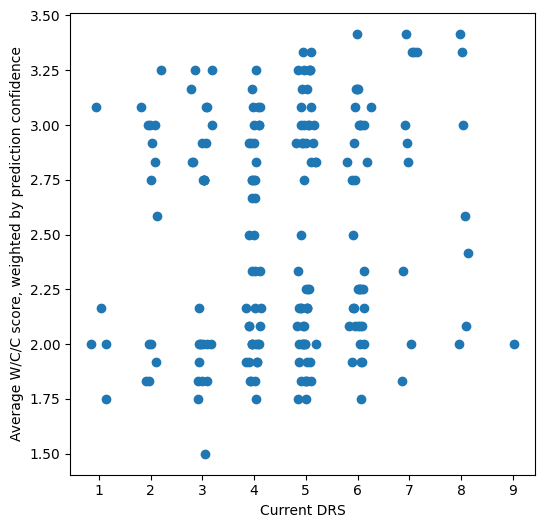

In [ ]:
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))
X = per_client_results['Current DRS'].to_numpy().reshape(-1,1)
Y = per_client_results['Overall'].to_numpy().reshape(-1,1)
ax.scatter(rand_jitter(X), Y)
ax.set_xlabel('Current DRS')
ax.set_ylabel('Average W/C/C score, weighted by prediction confidence')

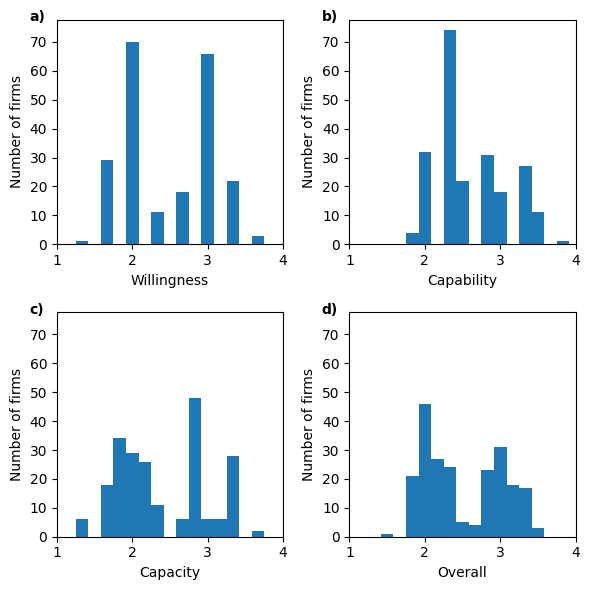

In [ ]:
fig, axes = matplotlib.pyplot.subplots(2, 2, figsize=(6,6))

cores_plus = ['Willingness', 'Capability', 'Capacity', 'Overall'] # 'Weighted Average']
xlabels = cores_plus[:3] + ['Overall']

labels = ['a)', 'b)', 'c)', 'd)']

y_max = 0
bins = numpy.linspace(1+(1/12), 4-(1/12), 18)

scaled_translation = matplotlib.transforms.ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)

for i, core in enumerate(cores_plus):
  ax = axes.flatten().tolist()[i]
  ax.hist(per_client_results[core], bins=bins)
  ax.set_xlabel(xlabels[i])
  ax.set_ylabel('Number of firms')
  ax.set_xlim(1, 4)
  y_max = max(y_max, float(ax.get_ylim()[1]))
  ax.text(
        0.0, 1, labels[i],
        transform=ax.transAxes + scaled_translation,
        va='top', fontsize='medium', fontweight='bold'
      )

for ax in axes.flatten().tolist():
  ax.set_ylim(0, y_max)

fig.tight_layout()

In [ ]:
per_client_results

,Client ID,Current DRS,Willingness,Capability,Capacity,Overall
0,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,6,3.333333,3.00,3.2,3.166667
1,01C7893A-F65C-A751-BF14-85C2422EEB21,3,3.000000,2.75,3.0,2.916667
2,02ACA5CA-A427-85C2-83F1-641E6C24C3B7,4,1.666667,2.00,1.8,1.833333
3,0369B4F9-9E83-E83D-9E6B-BF82E264A2BA,4,3.000000,2.75,3.4,3.083333
4,03D6895D-CDC3-B045-0038-D67ED790CFEB,4,2.666667,2.25,1.8,2.166667
...,...,...,...,...,...,...
215,eb08ecff-5bf9-e60a-9cbf-66e8050adf5a,3,2.000000,2.25,1.8,2.000000
216,eedd9207-123a-0efe-b23c-666b0cc9fd64,6,2.000000,2.25,2.0,2.083333
217,f02a9ef1-5fcd-5bf8-a059-673b3046b72a,2,3.000000,2.00,2.8,2.583333
218,f0924673-4134-48c9-3570-66e93ff15a47,4,2.000000,2.25,2.0,2.083333


In [ ]:
per_client_results

,Client ID,Current DRS,Willingness,Capability,Capacity,Overall
0,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,6,3.333333,3.00,3.2,3.166667
1,01C7893A-F65C-A751-BF14-85C2422EEB21,3,3.000000,2.75,3.0,2.916667
2,02ACA5CA-A427-85C2-83F1-641E6C24C3B7,4,1.666667,2.00,1.8,1.833333
3,0369B4F9-9E83-E83D-9E6B-BF82E264A2BA,4,3.000000,2.75,3.4,3.083333
4,03D6895D-CDC3-B045-0038-D67ED790CFEB,4,2.666667,2.25,1.8,2.166667
...,...,...,...,...,...,...
215,eb08ecff-5bf9-e60a-9cbf-66e8050adf5a,3,2.000000,2.25,1.8,2.000000
216,eedd9207-123a-0efe-b23c-666b0cc9fd64,6,2.000000,2.25,2.0,2.083333
217,f02a9ef1-5fcd-5bf8-a059-673b3046b72a,2,3.000000,2.00,2.8,2.583333
218,f0924673-4134-48c9-3570-66e93ff15a47,4,2.000000,2.25,2.0,2.083333


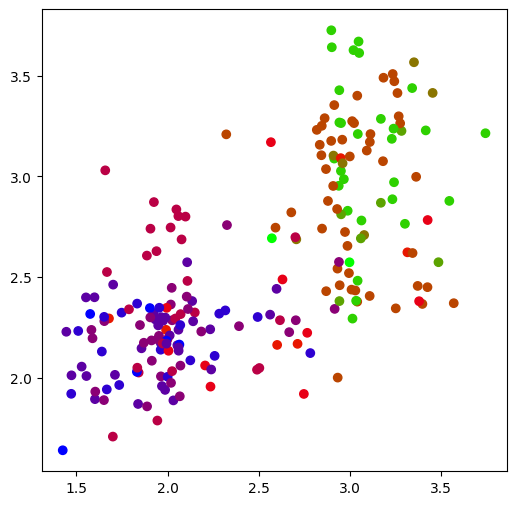

In [ ]:
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))

std = 0.1
ax.scatter(
    rand_jitter(per_client_results['Willingness'].to_numpy().reshape(-1, 1), stdev=std),
    rand_jitter(per_client_results['Capability'].to_numpy().reshape(-1, 1), stdev=std),
    c= per_client_results['Capacity'].to_numpy().reshape(-1, 1),
    cmap='brg'
  )

# Combined OLS model

In [ ]:
iv_cols = [
    # 'Number of GAFs',
    'Number of defrayed grants',
    'Number of withdrawn grants',

    # 'Log Turnover',
    # 'Log10 Turnover',

    # 'Number of FTE Employees (calc)',
    # 'Org Size by Number of FTE (calc)',
    'Is Micro?',
    'Is Medium?',

    'Current Digital Readiness Score (refer to PAS:1040)',
    # 'Anticipated resulting Digital Readiness Score (refer to PAS:1040)',
    # 'Anticipated increase in DRS',

    'Do you have a Digital Champion in place?',

    'How valuable did you find the involvement of your contact within the programme during the course of the support?',
    'How valuable did you find the GROWTHmapper and its report in identifying the key areas of supporting your business?',
    'How valuable did you find the support you received from the Expert Coach during the course of the programme?',

    'Willingness',
    'Capability',
    'Capacity',
]

# dv_col = 'Total actual amount claimed'
# dv_col = 'Total actual project spend'
# dv_col = 'Total firm contribution'
dv_col = 'Total high-intensity firm contribution'
# dv_col = 'Firm adopted I4.0 Tech?'
# dv_col = 'Max Scaled Grant Type'
# dv_col = 'Did High-Intensity Grants?'

Drop any firms with missing data for any of the IV or DV columns

In [ ]:
len(roadmaps_df[iv_cols+[dv_col]].dropna())

143

In [ ]:
model_data = roadmaps_df[iv_cols+[dv_col]].dropna()

Standardise values

In [ ]:
# for col in iv_cols:
#   model_data[col] = (model_data[col] - model_data[col].mean()) / model_data[col].std()
# model_data

In [ ]:
for col in iv_cols:
    test_cols = [c for c in iv_cols if c != col]
    test_data = roadmaps_df[test_cols+[dv_col]].dropna()
    print(f'{col}: {len(test_data)}')

Number of defrayed grants: 143
Number of withdrawn grants: 143
Is Micro?: 143
Is Medium?: 143
Current Digital Readiness Score (refer to PAS:1040): 151
Do you have a Digital Champion in place?: 147
How valuable did you find the involvement of your contact within the programme during the course of the support?: 143
How valuable did you find the GROWTHmapper and its report in identifying the key areas of supporting your business?: 143
How valuable did you find the support you received from the Expert Coach during the course of the programme?: 143
Willingness: 143
Capability: 143
Capacity: 143


Correlations

In [ ]:
if IN_COLAB:
  output_dir = os.path.join(dirpath, 'analysis', 'outputs')

grants_cols = ['Total actual amount claimed', 'Total actual project spend', 'Total firm contribution']

corrs = roadmaps_df[iv_cols+grants_cols].dropna().corr()
print(len(roadmaps_df[iv_cols+grants_cols].dropna()))
# corrs = roadmaps_df[['Willingness', 'Capability', 'Capacity']+grants_cols].dropna().corr()
# corrs
# corrs.to_csv(os.path.join(output_dir, 'correlations.csv'), index=False)

151


Fit the model

In [ ]:
X = model_data[iv_cols]
# X = model_data[['Willingness', 'Capability', 'Capacity']]
y = model_data[dv_col]

In [ ]:
X2 = statsmodels.api.add_constant(X)
est = statsmodels.api.OLS(y, X2.astype(float))
# est = statsmodels.discrete.discrete_model.Logit(y, X.astype(float))
est2 = est.fit()
print(est2.summary())

                                      OLS Regression Results                                      
Dep. Variable:     Total high-intensity firm contribution   R-squared:                       0.253
Model:                                                OLS   Adj. R-squared:                  0.184
Method:                                     Least Squares   F-statistic:                     3.672
Date:                                    Wed, 03 Jun 2026   Prob (F-statistic):           9.20e-05
Time:                                            12:22:41   Log-Likelihood:                -1295.3
No. Observations:                                     143   AIC:                             2617.
Df Residuals:                                         130   BIC:                             2655.
Df Model:                                              12                                         
Covariance Type:                                nonrobust                                         
          

# Sandpit

First order by W/C/C core

In [ ]:
all_preds_per_firms = all_results_df[['Client ID', 'Question', 'Prediction']].pivot(index='Client ID', columns='Question', values='Prediction')
questions_prompts = questions_prompts.sort_values(['Core', 'Category'])
all_preds_per_firms = all_preds_per_firms[questions_prompts['Question']]

In [ ]:
all_preds_per_firms.isna().any().any()

np.False_

In [ ]:
all_preds_per_firms['Does the company currently utilise any advanced technological capabilities that give it an advantage over competitors?'].std()

0.0

In [ ]:
all_preds_per_firms['Does the company currently utilise any advanced technological capabilities that give it an advantage over competitors?'].min()

3

In [ ]:
all_preds_per_firms['Does the company currently utilise any advanced technological capabilities that give it an advantage over competitors?'].max()

3

In [ ]:
all_preds_per_firms.corr().to_csv(os.path.join(output_dir, 'question_correlations_core.csv'), index=False)

Now order by Category

In [ ]:
questions_prompts = questions_prompts.sort_values(['Category', 'Core'])
all_preds_per_firms = all_preds_per_firms[questions_prompts['Question']]

In [ ]:
all_preds_per_firms.corr().to_csv(os.path.join(output_dir, 'question_correlations_category.csv'), index=False)

In [ ]:
questions_prompts

,Core,Category,Question,Level 1 - Absent/Reactive,Level 2 - Emerging/Informal,Level 3 - Defined/Aligned,Level 4 - Advanced/Integrated & Innovation Driven
14,Capacity,Customers/Markets,Does the company have long-term key customers ...,"The company relies on transactional, spot-mark...",Long-term relationships exist (often based on ...,The company has multi-year contracts or prefer...,The company doesn't just sell to customers; it...
1,Willingness,Management,Is the management team of the company open to ...,Management is closed or indifferent to externa...,Management shows ad-hoc or opportunistic inter...,Management is proactively and strategically op...,Collaboration is a core business pillar. Manag...
6,Capability,Management,Does the company have a range of managerial sk...,"""Firefighting"" management. Leadership focuses ...","""Intuitive"" or ""Hero-based"" management. Strate...",Process-driven leadership. Management uses KPI...,"""Visionary & Agile"" management. Leadership exc..."
11,Capacity,Management,Does the management of the company (especially...,"All decisions, including minor operational cha...",Management has authority over day-to-day produ...,"Management has a clear, documented mandate to ...",Management operates with high-level autonomy a...
2,Willingness,Production/Delivery,Are continuous improvement methods embedded wi...,Continuous improvement is non-existent or acci...,Continuous improvement efforts are siloed or e...,Continuous improvement is systematic and strat...,Continuous improvement is the organizational D...
7,Capability,Production/Delivery,Does the company have efficient processes and ...,"Reliance on paper-based records, basic spreads...","Introduction of standalone software (e.g., an ...",Implementation of an integrated ERP or modular...,A full-stack integrated ecosystem including ER...
12,Capacity,Production/Delivery,Does the company have the flexibility in its s...,"The company is set up for high-volume, static ...","Flexibility exists but is ""unmanaged."" The com...",The company uses formal change management and ...,"The company utilizes Digital Twins, agile manu..."
3,Willingness,Technology,Is the company aware of the possibilities offe...,The company shows no awareness of emerging tec...,The company has a vague or anecdotal awareness...,The company actively monitors technology devel...,"The company maintains a sophisticated, continu..."
8,Capability,Technology,Does the company currently utilise any advance...,"Reliance on tradtional, manual tools or standa...",Use of basic digital tools or isolated automat...,Widespread use of modern manufacturing tech (e...,"Utilization of frontier, cutting-edge technolo..."
13,Capacity,Technology,Does the company currently have the resources ...,The company has no dedicated budget for techno...,"Some funds are available for improvements, but...",The company maintains a dedicated digital/inno...,"Investment is seen as a continuous necessity, ..."
